# **Sistem Rekomendasi Content Based Filtering: Jurnal ArXiv**


# **Import Library**
Pada tahapan awal, lakukan import library yang akan digunakan dan akses env variable dari google collab untuk akses ke eksternal source yang lebih mudah (Hugging Face, Kaggle)

In [84]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import gc
import re
import nltk
import torch

from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer
from text_unidecode import unidecode
from google.colab import userdata
from huggingface_hub import login

from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

In [85]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [86]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [87]:
# Retrieve the token safely from your secrets vault
hf_token = userdata.get('HF_TOKEN')

# Log in to the Hugging Face Hub
login(hf_token)

# **Download Dataset dari Kaggle ([Dataset](https://www.kaggle.com/datasets/Cornell-University/arxiv/data))**
Download dataset dari kaggle, setelahnya mengecek list nama file yang terdapat pada folder download untuk dilakukan validasi file

In [88]:
# Download latest version
path = kagglehub.dataset_download("Cornell-University/arxiv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'arxiv' dataset.
Path to dataset files: /kaggle/input/arxiv


In [89]:
for f in os.listdir(path):
  print(f)

arxiv-metadata-oai-snapshot.json


## **Contoh Isi Dataset Yang Sudah Didownload**

```
{
  "id": "0704.0001",
  "submitter": "Pavel Nadolsky",
  "authors": "C. Bal'azs, E. L. Berger, P. M. Nadolsky, C.-P. Yuan",
  "title": "Calculation of prompt diphoton production cross sections at Tevatron and\n  LHC energies",
  "comments": "37 pages, 15 figures; published version",
  "journal-ref": "Phys.Rev.D76:013009,2007",
  "doi": "10.1103/PhysRevD.76.013009",
  "report-no": "ANL-HEP-PR-07-12",
  "categories": "hep-ph",
  "license": null,
  "abstract": "  A fully differential calculation in perturbative quantum chromodynamics is\npresented for the production of massive photon pairs at hadron colliders. All\nnext-to-leading order perturbative contributions from quark-antiquark,\ngluon-(anti)quark, and gluon-gluon subprocesses are included, as well as\nall-orders resummation of initial-state gluon radiation valid at\nnext-to-next-to-leading logarithmic accuracy. The region of phase space is\nspecified in which the calculation is most reliable. Good agreement is\ndemonstrated with data from the Fermilab Tevatron, and predictions are made for\nmore detailed tests with CDF and DO data. Predictions are shown for\ndistributions of diphoton pairs produced at the energy of the Large Hadron\nCollider (LHC). Distributions of the diphoton pairs from the decay of a Higgs\nboson are contrasted with those produced from QCD processes at the LHC, showing\nthat enhanced sensitivity to the signal can be obtained with judicious\nselection of events.\n",
  "versions": [
    {
      "version": "v1",
      "created": "Mon, 2 Apr 2007 19:18:42 GMT"
    },
    {
      "version": "v2",
      "created": "Tue, 24 Jul 2007 20:10:27 GMT"
    }
  ],
  "update_date": "2008-11-26",
  "authors_parsed": [
    [
      "Balázs",
      "C.",
      ""
    ],
    [
      "Berger",
      "E. L.",
      ""
    ],
    [
      "Nadolsky",
      "P. M.",
      ""
    ],
    [
      "Yuan",
      "C. -P.",
      ""
    ]
  ]
}
```



Dari total 14 kolom yang terdapat pada data JSON tersebut, hanya digunakan 5 kolom untuk sistem rekomendasi yaitu:

1. Authors
2. Title
3. Categories
4. Abstract
5. Update_date

Hal tersebut dikarenakan beberapa kolom lainnya seperti doi, version, id dan lainnya, tidak terlalu relevan untuk dijadikan parameter dalam sistem rekomendasi

## **Function Section Untuk Akses Data**
Membuat function untuk load dataset besar agar tidak menghabiskan banyak ram (1 baris per 1 pemanggilan).

In [90]:
def get_data(file_path):
  with open(file_path) as f:
    for line in f:
       yield json.loads(line)

Pembuatan function load_data untuk membaca dictionary dari return get_data menjadi dataframe. Sebagai tambahan, dilakukan parsing data dengan menambahkan tahun yang bertindak sebagai filter pada data.

In [91]:
file_path = os.path.join(path, "arxiv-metadata-oai-snapshot.json")

def load_data(file_path, start_year=None, end_year=None):
  """
  Function untuk load data dari file JSON, jika start_year==None dan end_year=None maka akan load semua data, jika tidak maka akan load data dari tahun yang ditentukan
  input: file_path, start_year, end_year
  return: dataframe
  """
  generator_data = get_data(file_path)

  dataframe = {
    'authors': [],
    'title': [],
    'categories': [],
    'abstract': [],
    'update_date': [],
    'year': [],
    'month': []
  }

  for paper in generator_data:
    try:
      year_date = int(paper['update_date'].split('-')[0])
      month_date = int(paper['update_date'].split('-')[1])
      is_valid = False

      # 1. Jika kedua filter kosong, semua data lolos
      if start_year is None and end_year is None:
          is_valid = True

      # 2. Jika ada rentang tahun (dua-duanya diisi)
      elif start_year is not None and end_year is not None:
          if start_year <= year_date <= end_year:
              is_valid = True

      # 3. Jika hanya end_year yang diisi (start_year kosong)
      elif start_year is None and end_year is not None:
          if year_date <= end_year:
              is_valid = True

      # 4. Jika hanya start_year yang diisi (end_year kosong)
      elif start_year is not None and end_year is None:
          if start_year <= year_date:
              is_valid = True

      # Jika lolos filter, masukkan ke storage
      if is_valid:
        dataframe['authors'].append(paper.get('authors', ''))
        dataframe['title'].append(paper.get('title', ''))
        dataframe['categories'].append(paper.get('categories', ''))
        dataframe['abstract'].append(paper.get('abstract', ''))
        dataframe['update_date'].append(paper.get('update_date', ''))
        dataframe['year'].append(year_date)
        dataframe['month'].append(month_date)

    except (KeyError, ValueError, IndexError):
      continue
      # Mengantisipasi jika ada baris data yang rusak atau format tanggal salah

  del generator_data
  gc.collect()

  return pd.DataFrame(dataframe)

## **Akses Data**
Implementasikan load_data untuk mengakses file yang sudah didownload, kemudian tampilkan 5 data teratas dan terbawah untuk validasi function.

In [92]:
df = load_data(file_path, start_year=2026, end_year=None)

In [93]:
df.head(5)

,authors,title,categories,abstract,update_date,year,month
0,Simon J.A. Malham and Anke Wiese,Stochastic Lie group integrators,math.NA cs.NA,We present Lie group integrators for nonline...,2026-06-03,2026,6
1,Lester Ingber,Real Options for Project Schedules (ROPS),cs.CE cond-mat.stat-mech cs.MS cs.NA math.NA p...,Real Options for Project Schedules (ROPS) ha...,2026-06-03,2026,6
2,"D. Wilczak, P. Zgliczy\'nski",$C^r$-Lohner algorithm,math.NA cs.NA math.DS,We present a Lohner type algorithm for the c...,2026-06-03,2026,6
3,Sebastien Zimmermann,Stability of a colocated finite volume scheme ...,math.NA cs.NA,We introduce a finite volume scheme for the ...,2026-06-03,2026,6
4,Sebastien Zimmermann,Stability of a finite volume scheme for the in...,math.NA cs.NA,We introduce a finite volume scheme for the ...,2026-06-03,2026,6


In [94]:
df.tail(5)

,authors,title,categories,abstract,update_date,year,month
237221,"Stefan Heinrich, Erich Novak",On a Problem in Quantum Summation,quant-ph cs.NA math.NA,We consider the computation of the mean of s...,2026-06-03,2026,6
237222,Zbyszek P. Karkuszewski,Harmonic inversion helps to beat time-energy u...,quant-ph cs.NA math.NA,It is impossible to obtain accurate frequenc...,2026-06-03,2026,6
237223,Zbyszek P. Karkuszewski,Spectral analysis of short time signals,quant-ph cs.NA math.NA math.SP,The very old problem of extracting frequenci...,2026-06-03,2026,6
237224,"Jorgen Cederlof, Jan-{\AA}ke Larsson",Security aspects of the Authentication used in...,quant-ph,Unconditionally secure message authenticatio...,2026-03-05,2026,3
237225,Merced Montesinos and Abdel P\'erez-Lorenzana,Minimal coupling and Feynman's proof,quant-ph hep-th physics.class-ph,The non quantum relativistic version of the ...,2026-04-01,2026,4


Cek tahun yang terdapat pada dataset untuk memastikan bahwa filter sudah berjalan dengan benar

In [95]:
df['year'].unique()

array([2026])

Cek informasi dan deskripsi dari dataset, memastikan bahwa tidak ada kesalahan type data maupun persebaran data

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237226 entries, 0 to 237225
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   authors      237226 non-null  object
 1   title        237226 non-null  object
 2   categories   237226 non-null  object
 3   abstract     237226 non-null  object
 4   update_date  237226 non-null  object
 5   year         237226 non-null  int64 
 6   month        237226 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 12.7+ MB


# **Exploratory Data Analysis**

Exploratory Data Analysis Dilakukan Untuk Menganalisis Informasi Yang Terdapat Pada Data, dimana tahapan EDA ini bisa dilakukan lebih dari 1x tergantung pada kondisi pada dataset.

## **Function Section Untuk EDA**
Section yang berfokuskan pada eksplorasi dan analisis data untuk preprocessing, seperti mencari nilai nan dan duplikat

In [97]:
def cek_nan(data):
  """
  Function yang digunakan untuk memeriksa nilai nan dari data
  input   : data
  output  : nan_info (DataFrame)
  return  : nan_info (DataFrame)
  """
  nan_info = pd.DataFrame(data.isna().sum().sort_values(ascending=False), columns=['Jumlah Nilai Missing'])

  if nan_info['Jumlah Nilai Missing'].sum() == 0:
    print("Tidak ada nilai missing")
    return None
  else:
    nan_info['Persentase Nilai Missing (%)'] = ((nan_info['Jumlah Nilai Missing'] / len(data)) * 100).round(3)

    # return data dengan nilai missing, apabila ingin mereturn keseluruhan data maka ubah menjadi return nan_info
    return nan_info[nan_info['Jumlah Nilai Missing'] > 0]


def visualize_row_with_nan(data, method='all', columns=None):
  """
  Procedure yang digunakan untuk menvisualisasikan baris yang mengandung NaN berdasarkan metode yang dipilih
  input   : data, method, columns
  output  : baris_nan (DataFrame)
  """
  try:
    if method not in ['all', 'column', 'columns']:
      raise ValueError("Metode tidak valid. Pilih salah satu dari 'all', 'column', 'columns'.")

    if method == 'all':
      display(data[data.isna().any(axis=1)])

    elif method == 'column':
      if not isinstance(columns, str):
          raise TypeError("Untuk metode 'column', argumen 'columns' harus berupa String.")
      if columns not in data.columns:
          raise KeyError(f"Kolom '{columns}' tidak ditemukan dalam DataFrame.")
      display(data[data[columns].isna()])

    elif method == 'columns':
      if not isinstance(columns, list):
          raise TypeError("Untuk metode 'columns', argumen 'columns' harus berupa list.")
      for column in columns:
          if column not in data.columns:
              raise KeyError(f"Kolom '{column}' tidak ditemukan dalam DataFrame.")
      display(data[data[columns].isna().all(axis=1)])

  except (TypeError, KeyError) as e:
    print(f"Kesalahan dalam memproses data: {e}")


def visualize_row_with_duplicated(data, column=None):
  """
  Procedure yang digunakan untuk menvisualisasikan baris yang mengandung data duplikat
  input   : data
  output  : baris_duplikat (DataFrame)
  """
  duplicated_count = data.duplicated(subset=column).sum()

  if duplicated_count > 0:
    print("Jumlah Data Duplikat :", duplicated_count)
    all_duplicates = data[data.duplicated(subset=column, keep=False)]

    if column is None:
      duplicate_indices = all_duplicates.groupby(list(all_duplicates.columns)).groups
    else:
      duplicate_indices = all_duplicates.groupby(column).groups

    print("Pasangan Data Duplikat :")
    for group_indices in duplicate_indices.values():
      if len(group_indices) > 1:
        display(data.iloc[list(group_indices)])
        print("\n")
  else:
    print("Tidak ada data duplikat")

## **Function Section Untuk Pre-Processing**
Section yang difokuskan untuk pre-processing data teks, dengan fokus pada case folding serta regex untuk membersihkan simbol, logo, latex, dan sebagainya

In [98]:
lemmatizer = WordNetLemmatizer()

In [99]:
def lower_case(data):
  """Case Folding. Mengecilkan huruf agar seragam"""
  data = data.str.lower()
  return data

def pembersihan_dasar(teks):
  """Hanya menangani unidecode dan spasi ganda. Aman untuk SEMUA kolom."""
  teks = unidecode(teks)
  teks = re.sub(r'\s+', ' ', teks).strip()
  return teks

def bersihkan_categories(teks):
  """
  Mengubah format spasi antar kategori menjadi dipisahkan oleh koma.
  Contoh: 'math.na cs.na' -> 'math.na, cs.na'
  """
  if not isinstance(teks, str):
    return teks

  # Mengganti spasi (baik satu maupun lebih) di tengah teks dengan koma + spasi
  teks = re.sub(r'\s+', ', ', teks.strip())

  # Kembalikan ke pembersihan dasar untuk merapikan sisa spasi & unidecode
  return pembersihan_dasar(teks)

def bersihkan_title(teks):
  """
  Khusus membersihkan judul dari simbol matematika LaTeX
  """
  if not isinstance(teks, str):
    return teks

  # 1. Hilangkan tanda subscript (_)
  teks = re.sub(r'_', ' ', teks)

  # 2. Hilangkan kurung kurawal penanda grup LaTeX { } dan beberapa simbol
  teks = re.sub(r'[\{\}\_\^\$\\\"]', '', teks)

  return pembersihan_dasar(teks)

def bersihkan_author(teks):
  """Khusus menghapus afiliasi dan indeks angka."""
  # 1. Hapus catatan kaki institusi kompleks di paling ujung jika ada format ((1) ...)
  teks = re.sub(r'\s*\(\s*\([0-9]+\).*$', '', teks)

  # 2. Hapus semua jenis kurung berisi afiliasi teks maupun angka
  # Pola [^)]+ artinya menghapus apa pun di dalam kurung selama itu bukan kurung tutup
  teks = re.sub(r'\s*\([^)]+\)', '', teks)

  # 3. Bersihkan aksen LaTeX standar seperti \'e -> e, \`a -> a
  teks = re.sub(r"\\[\'\"\`\^~]([a-zA-Z])", r"\1", teks)

  # 4. Bersihkan aksen LaTeX Cedilla seperti \c{c} -> c
  # Pola ini mencari \c{ dilanjutkan huruf, lalu ditutup }
  teks = re.sub(r"\\[cv]\{([a-zA-Z]+)\}", r"\1", teks)

  # 5. Bersihkan karakter spesial LaTeX di dalam kurung kurawal seperti {\l} -> l
  # Pola ini mencari '{' diikuti '\' dan satu huruf, lalu ditutup dengan '}'
  teks = re.sub(r"\{\\([a-zA-Z])[a-zA-Z]*\}", r"\1", teks)

  return pembersihan_dasar(teks)

def bersihkan_abstract(teks):
  """Khusus menangani LaTeX dan rumus matematika."""
  teks = re.sub(r"\\[\'\"\`\^~]([a-zA-Z])", r"\1", teks) # Kollar
  teks = re.sub(r'\s*:=\s*', ' ', teks) # Operator :=
  teks = re.sub(r'[\{\}\$\_\\]', '', teks) # Hilangkan kurung kurawal penanda grup { } dan beberapa simbol

  return pembersihan_dasar(teks)


def preprocessing_khusus_tfidf(teks):
  """
  Fungsi ini khusus untuk mengubah kata menjadi bentuk dasarnya (Lemmatization).
  Hanya digunakan untuk pendekatan TF-IDF, BUKAN untuk Sentence Transformers.
  """
  if not isinstance(teks, str):
    return teks

  # Memecah kalimat menjadi list kata (Tokenisasi)
  tokens = word_tokenize(teks)

  # Mengubah setiap kata ke bentuk dasar (misal: "images" -> "image", "learning" -> "learn")
  teks_lemmatized = " ".join([lemmatizer.lemmatize(kata) for kata in tokens if kata.isalnum()])

  return teks_lemmatized

## **Case Folding**
Implementasi function lower_case untuk memastikan bahwa data sudah seragam dan menghindari terdapatnya data yang sama namun penulisan nya berbeda sehingga tidak terdeteksi duplikat.

In [100]:
df['authors'] = lower_case(df['authors'])
df['title'] = lower_case(df['title'])
df['categories'] = lower_case(df['categories'])
df['abstract'] = lower_case(df['abstract'])

## **Cek Kolom NaN dan Duplikat**

Implementasi function cek_nan untuk memastikan bahwa tidak ada nilai yang kosong pada dataset.

In [101]:
cek_nan(df)

Tidak ada nilai missing


Mengimplemenasikan procedure visualize_row_with_duplicated untuk memeriksa data duplikat dalam dataset serta menampilkan baris datanya

In [102]:
visualize_row_with_duplicated(df, column=None)

Jumlah Data Duplikat : 1
Pasangan Data Duplikat :


,authors,title,categories,abstract,update_date,year,month
84499,"kuniaki saito, risa shinoda, shohei tanaka, to...",haldec-bench: benchmarking hallucination detec...,cs.cv,hallucination detection in captions (haldec) a...,2026-03-25,2026,3
155572,"kuniaki saito, risa shinoda, shohei tanaka, to...",haldec-bench: benchmarking hallucination detec...,cs.cv,hallucination detection in captions (haldec) a...,2026-03-25,2026,3


Dari total 237226 data, terdapat 1 data yang merupakan duplikat. Namun jika diperhatikan, kolom update_date sebenarnya sudah tidak diperlukan karena kita sudah memiliki kolom year dan month yang didapatkan melalui ekstraksi kolom update_date, sehingga kita akan melakukan validasi ulang dahulu tanpa kolom update_date, untuk memastikan bahwa data sudah benar tidak memiliki duplikat

In [103]:
df.drop('update_date', axis=1, inplace=True)

Implementasikan ulang procedure visualize_row_with_duplicated untuk memastikan bahwa data sudah benar bersih dari duplikat dan tidak ada duplikat yang dikarenakan kolom update_date maupun error data, tapi sebelum itu, perlu diingat bahwa month juga bersumber dari update_date dan ada kemungkinan bahwa 1 paper diupdate beberapa kali dalam bulan yang sama, sehingga lebih baik pada pemeriksaan duplikat selanjutnya, digunakan subset kolom untuk pemeriksaan nya.

In [104]:
subset_columns = ['authors', 'title', 'categories', 'abstract']

visualize_row_with_duplicated(df, column=subset_columns)

Jumlah Data Duplikat : 3
Pasangan Data Duplikat :


,authors,title,categories,abstract,year,month
84499,"kuniaki saito, risa shinoda, shohei tanaka, to...",haldec-bench: benchmarking hallucination detec...,cs.cv,hallucination detection in captions (haldec) a...,2026,3
155572,"kuniaki saito, risa shinoda, shohei tanaka, to...",haldec-bench: benchmarking hallucination detec...,cs.cv,hallucination detection in captions (haldec) a...,2026,3


,authors,title,categories,abstract,year,month
65255,"zhihao gong, zeyu sun, dong huang, qingyuan li...",trace: evaluating execution efficiency of llm-...,cs.se,while large language models (llms) have substa...,2026,3
156798,"zhihao gong, zeyu sun, dong huang, qingyuan li...",trace: evaluating execution efficiency of llm-...,cs.se,while large language models (llms) have substa...,2026,4


,authors,title,categories,abstract,year,month
122875,"ziyu luo, lin chen, qiang qu, xiaoming chen an...",dynfoa: generating first-order ambisonics with...,cs.sd,spatial audio is crucial for immersive 360-deg...,2026,5
173145,"ziyu luo, lin chen, qiang qu, xiaoming chen an...",dynfoa: generating first-order ambisonics with...,cs.sd,spatial audio is crucial for immersive 360-deg...,2026,4


Ternyata hipotesis tersebut benar, dari 237226 terdapat 2 data tambahan yang merupakan duplikat karena berasal dari update_date sehingga total data duplikat sebanyak 3. Sehingga selanjutnya, kita bisa langsung melanjutkan tahapan dengan drop data duplikat dan reset index dari awal

In [105]:
df.drop_duplicates(subset=subset_columns, keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)

Cek ulang informasi dan jumlah data pada dataset untuk memastikan bahwa penghapusan nilai duplikat sudah berhasil serta tidak ada error selama proses berjalan

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237223 entries, 0 to 237222
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   authors     237223 non-null  object
 1   title       237223 non-null  object
 2   categories  237223 non-null  object
 3   abstract    237223 non-null  object
 4   year        237223 non-null  int64 
 5   month       237223 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 10.9+ MB


Cek 5 kolom teratas dan terbawah untuk validasi function

In [107]:
df.head(5)

,authors,title,categories,abstract,year,month
0,simon j.a. malham and anke wiese,stochastic lie group integrators,math.na cs.na,we present lie group integrators for nonline...,2026,6
1,lester ingber,real options for project schedules (rops),cs.ce cond-mat.stat-mech cs.ms cs.na math.na p...,real options for project schedules (rops) ha...,2026,6
2,"d. wilczak, p. zgliczy\'nski",$c^r$-lohner algorithm,math.na cs.na math.ds,we present a lohner type algorithm for the c...,2026,6
3,sebastien zimmermann,stability of a colocated finite volume scheme ...,math.na cs.na,we introduce a finite volume scheme for the ...,2026,6
4,sebastien zimmermann,stability of a finite volume scheme for the in...,math.na cs.na,we introduce a finite volume scheme for the ...,2026,6


In [108]:
df.tail(5)

,authors,title,categories,abstract,year,month
237218,"stefan heinrich, erich novak",on a problem in quantum summation,quant-ph cs.na math.na,we consider the computation of the mean of s...,2026,6
237219,zbyszek p. karkuszewski,harmonic inversion helps to beat time-energy u...,quant-ph cs.na math.na,it is impossible to obtain accurate frequenc...,2026,6
237220,zbyszek p. karkuszewski,spectral analysis of short time signals,quant-ph cs.na math.na math.sp,the very old problem of extracting frequenci...,2026,6
237221,"jorgen cederlof, jan-{\aa}ke larsson",security aspects of the authentication used in...,quant-ph,unconditionally secure message authenticatio...,2026,3
237222,merced montesinos and abdel p\'erez-lorenzana,minimal coupling and feynman's proof,quant-ph hep-th physics.class-ph,the non quantum relativistic version of the ...,2026,4


# **Pre-Processing Teks**
Implementasikan function preprocessing untuk masing-masing kolom kecuali year, untuk categories hanya dilakukan pembersihan dasar untuk menghilangkan spasi berlebih dan unicode serta penambahan (,). Disimpan dalam dataframe baru agar data lama tidak hilang

In [109]:
tqdm.pandas(desc="Proses Pre-Processing Teks")

df_preprocessed = df.assign(
    authors=df['authors'].progress_apply(bersihkan_author),
    title=df['title'].progress_apply(bersihkan_title),
    categories=df['categories'].progress_apply(bersihkan_categories),
    abstract=df['abstract'].progress_apply(bersihkan_abstract),
    year=df['year'],
    month=df['month']
)

Proses Pre-Processing Teks:   0%|          | 0/237223 [00:00<?, ?it/s]

Proses Pre-Processing Teks:   0%|          | 0/237223 [00:00<?, ?it/s]

Proses Pre-Processing Teks:   0%|          | 0/237223 [00:00<?, ?it/s]

Proses Pre-Processing Teks:   0%|          | 0/237223 [00:00<?, ?it/s]

Cek 5 kolom teratas dan terbawah untuk validasi function

In [110]:
df_preprocessed.head(5)

,authors,title,categories,abstract,year,month
0,simon j.a. malham and anke wiese,stochastic lie group integrators,"math.na, cs.na",we present lie group integrators for nonlinear...,2026,6
1,lester ingber,real options for project schedules (rops),"cs.ce, cond-mat.stat-mech, cs.ms, cs.na, math....",real options for project schedules (rops) has ...,2026,6
2,"d. wilczak, p. zgliczynski",cr-lohner algorithm,"math.na, cs.na, math.ds",we present a lohner type algorithm for the com...,2026,6
3,sebastien zimmermann,stability of a colocated finite volume scheme ...,"math.na, cs.na",we introduce a finite volume scheme for the tw...,2026,6
4,sebastien zimmermann,stability of a finite volume scheme for the in...,"math.na, cs.na",we introduce a finite volume scheme for the tw...,2026,6


In [111]:
df_preprocessed.tail(5)

,authors,title,categories,abstract,year,month
237218,"stefan heinrich, erich novak",on a problem in quantum summation,"quant-ph, cs.na, math.na",we consider the computation of the mean of seq...,2026,6
237219,zbyszek p. karkuszewski,harmonic inversion helps to beat time-energy u...,"quant-ph, cs.na, math.na",it is impossible to obtain accurate frequencie...,2026,6
237220,zbyszek p. karkuszewski,spectral analysis of short time signals,"quant-ph, cs.na, math.na, math.sp",the very old problem of extracting frequencies...,2026,6
237221,"jorgen cederlof, jan-ake larsson",security aspects of the authentication used in...,quant-ph,unconditionally secure message authentication ...,2026,3
237222,merced montesinos and abdel perez-lorenzana,minimal coupling and feynman's proof,"quant-ph, hep-th, physics.class-ph",the non quantum relativistic version of the pr...,2026,4


## **Explarotory Data Analysis Setelah Pre-Processing**

### **Top 10 Kategori Terbanyak Dalam Data**

In [112]:
count_top_10_categories = df_preprocessed['categories'].str.split(', ', expand=True).stack().value_counts().head(10)
count_top_10_categories

,count
cs.lg,35643
cs.ai,35350
cs.cv,23407
cs.na,20720
math.na,20720
cs.cl,16842
quant-ph,13849
eess.sy,13224
cs.sy,13224
math.oc,9165


/tmp/ipykernel_633/4033441347.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=count_top_10_categories.index, y=count_top_10_categories.values, palette='viridis')


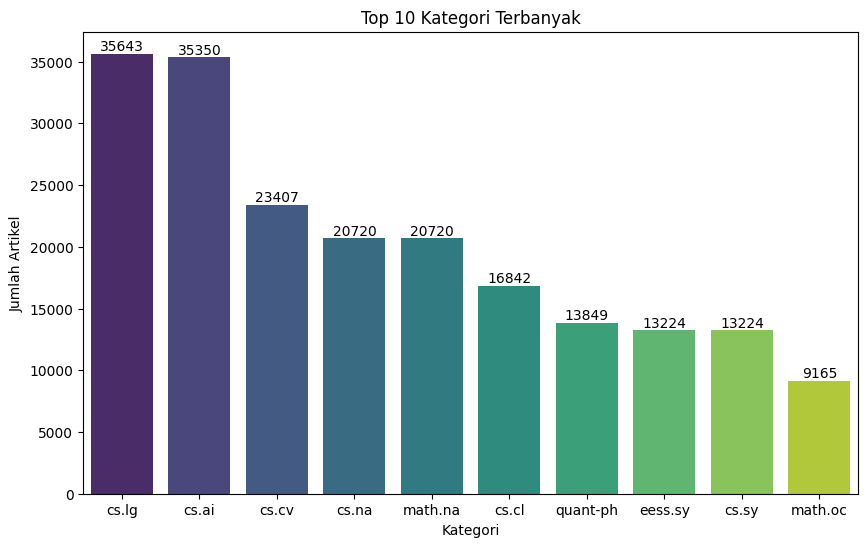

In [113]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=count_top_10_categories.index, y=count_top_10_categories.values, palette='viridis')
plt.title('Top 10 Kategori Terbanyak')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Artikel')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2, p.get_height()), # p.get_x(): Koordinat x atau titik kiri batang, p.get_width() / 2: Lebar batang / 2, p.get_height(): Koordinat y
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

### **Proporsi Angka Terbit Perbulan**

In [114]:
count_monthly_publication = df_preprocessed['month'].value_counts().sort_index()
count_monthly_publication

,count
month,
1,32013
2,33406
3,42247
4,42139
5,48729
6,38689


/tmp/ipykernel_633/3869523681.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=count_monthly_publication.index, y=count_monthly_publication.values, palette='viridis')


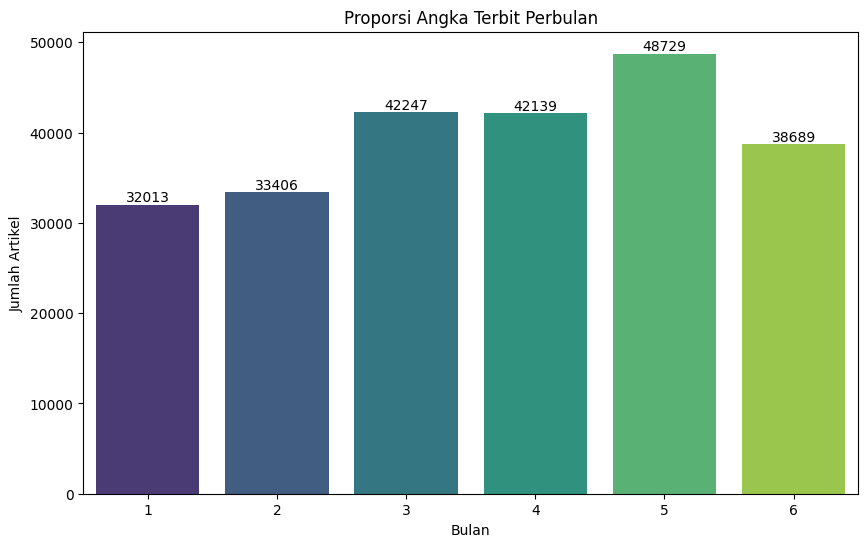

In [115]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=count_monthly_publication.index, y=count_monthly_publication.values, palette='viridis')
plt.title('Proporsi Angka Terbit Perbulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Artikel')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2, p.get_height()), # p.get_x(): Koordinat x atau titik kiri batang, p.get_width() / 2: Lebar batang / 2, p.get_height(): Koordinat y
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

# **Feature Engineering**
Buat kolom untuk mengkombinasikan teks title dan abstract, digunakan untuk melatih model pre-trained embedding sehingga dapat mengakses makna semantik yang lebih kaya pada ruang vektor. Pemilihan 2 kolom ini dikarenakan 2 kolom ini memiliki besaran kata paling banyak dibandingkan year, author, maupun categories, sehingga jika year, author, maupun categories dimasukkan dalam model embedding, maka kemungkinan besar 3 kolom tersebut tidak akan berpengaruh signifikan karena mayoritas vektor berasal dari title dan abstract

In [116]:
df_preprocessed['combined_text'] = (
    "title: " + df_preprocessed['title'] + ". " +
    "abstract: " + df_preprocessed['abstract']
)

Cek 5 kolom teratas dan terbawah untuk validasi feature

In [117]:
df_preprocessed.head(5)

,authors,title,categories,abstract,year,month,combined_text
0,simon j.a. malham and anke wiese,stochastic lie group integrators,"math.na, cs.na",we present lie group integrators for nonlinear...,2026,6,title: stochastic lie group integrators. abstr...
1,lester ingber,real options for project schedules (rops),"cs.ce, cond-mat.stat-mech, cs.ms, cs.na, math....",real options for project schedules (rops) has ...,2026,6,title: real options for project schedules (rop...
2,"d. wilczak, p. zgliczynski",cr-lohner algorithm,"math.na, cs.na, math.ds",we present a lohner type algorithm for the com...,2026,6,title: cr-lohner algorithm. abstract: we prese...
3,sebastien zimmermann,stability of a colocated finite volume scheme ...,"math.na, cs.na",we introduce a finite volume scheme for the tw...,2026,6,title: stability of a colocated finite volume ...
4,sebastien zimmermann,stability of a finite volume scheme for the in...,"math.na, cs.na",we introduce a finite volume scheme for the tw...,2026,6,title: stability of a finite volume scheme for...


In [118]:
df_preprocessed.tail(5)

,authors,title,categories,abstract,year,month,combined_text
237218,"stefan heinrich, erich novak",on a problem in quantum summation,"quant-ph, cs.na, math.na",we consider the computation of the mean of seq...,2026,6,title: on a problem in quantum summation. abst...
237219,zbyszek p. karkuszewski,harmonic inversion helps to beat time-energy u...,"quant-ph, cs.na, math.na",it is impossible to obtain accurate frequencie...,2026,6,title: harmonic inversion helps to beat time-e...
237220,zbyszek p. karkuszewski,spectral analysis of short time signals,"quant-ph, cs.na, math.na, math.sp",the very old problem of extracting frequencies...,2026,6,title: spectral analysis of short time signals...
237221,"jorgen cederlof, jan-ake larsson",security aspects of the authentication used in...,quant-ph,unconditionally secure message authentication ...,2026,3,title: security aspects of the authentication ...
237222,merced montesinos and abdel perez-lorenzana,minimal coupling and feynman's proof,"quant-ph, hep-th, physics.class-ph",the non quantum relativistic version of the pr...,2026,4,title: minimal coupling and feynman's proof. a...


## **Pre-Processing Tambahan Untuk Model TF-IDF**
Mengimplementasikan function preprocessing khusus model TF-IDF serta penghapusan stop word.

In [119]:
tqdm.pandas(desc="Proses Pre-Processing Teks TF-IDF")
df_preprocessed['combined_text_tfidf'] = df_preprocessed['combined_text'].progress_apply(preprocessing_khusus_tfidf)

Proses Pre-Processing Teks TF-IDF:   0%|          | 0/237223 [00:00<?, ?it/s]

Cek 5 kolom teratas dan terbawah untuk validasi feature

In [120]:
df_preprocessed.head(5)

,authors,title,categories,abstract,year,month,combined_text,combined_text_tfidf
0,simon j.a. malham and anke wiese,stochastic lie group integrators,"math.na, cs.na",we present lie group integrators for nonlinear...,2026,6,title: stochastic lie group integrators. abstr...,title stochastic lie group integrator abstract...
1,lester ingber,real options for project schedules (rops),"cs.ce, cond-mat.stat-mech, cs.ms, cs.na, math....",real options for project schedules (rops) has ...,2026,6,title: real options for project schedules (rop...,title real option for project schedule rops ab...
2,"d. wilczak, p. zgliczynski",cr-lohner algorithm,"math.na, cs.na, math.ds",we present a lohner type algorithm for the com...,2026,6,title: cr-lohner algorithm. abstract: we prese...,title algorithm abstract we present a lohner t...
3,sebastien zimmermann,stability of a colocated finite volume scheme ...,"math.na, cs.na",we introduce a finite volume scheme for the tw...,2026,6,title: stability of a colocated finite volume ...,title stability of a colocated finite volume s...
4,sebastien zimmermann,stability of a finite volume scheme for the in...,"math.na, cs.na",we introduce a finite volume scheme for the tw...,2026,6,title: stability of a finite volume scheme for...,title stability of a finite volume scheme for ...


In [121]:
df_preprocessed.tail(5)

,authors,title,categories,abstract,year,month,combined_text,combined_text_tfidf
237218,"stefan heinrich, erich novak",on a problem in quantum summation,"quant-ph, cs.na, math.na",we consider the computation of the mean of seq...,2026,6,title: on a problem in quantum summation. abst...,title on a problem in quantum summation abstra...
237219,zbyszek p. karkuszewski,harmonic inversion helps to beat time-energy u...,"quant-ph, cs.na, math.na",it is impossible to obtain accurate frequencie...,2026,6,title: harmonic inversion helps to beat time-e...,title harmonic inversion help to beat uncertai...
237220,zbyszek p. karkuszewski,spectral analysis of short time signals,"quant-ph, cs.na, math.na, math.sp",the very old problem of extracting frequencies...,2026,6,title: spectral analysis of short time signals...,title spectral analysis of short time signal a...
237221,"jorgen cederlof, jan-ake larsson",security aspects of the authentication used in...,quant-ph,unconditionally secure message authentication ...,2026,3,title: security aspects of the authentication ...,title security aspect of the authentication us...
237222,merced montesinos and abdel perez-lorenzana,minimal coupling and feynman's proof,"quant-ph, hep-th, physics.class-ph",the non quantum relativistic version of the pr...,2026,4,title: minimal coupling and feynman's proof. a...,title minimal coupling and feynman proof abstr...


# **Ekstraksi Teks**
Tahapan ekstraksi informasi semantik pada teks ke dalam representasi angka

## **TF-IDF Vectorizer**
Mengisialisasi model ekstraksi teks ke angka yang memanfaatkan bag of word atau jumlah kata pada suatu dokumen

In [122]:
# Gunakan stop_words='english' untuk membuang kata hubung
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=10000, min_df=5, max_df=0.8)

# Masukkan kolom yang sudah di-lemmatize
tfidf_matrix = tfidf_vectorizer.fit_transform(df_preprocessed['combined_text_tfidf'])

## **Model Pre-Trained Embedding**
Menginisialisasi model embedding transformer untuk dapat mengekstrak makna semantik dari teks ke dalam representasi ruang vektor.

In [123]:
model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
# model = SentenceTransformer('sentence-transformers/allenai-specter', device=device)
embeddings = model.encode(df_preprocessed['combined_text'].tolist(), batch_size=64, show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3707 [00:00<?, ?it/s]

# **Model Pengelompokkan Untuk Mencari Kelompok Data Yang Memiliki Kedekatan Semantik**


## **Nearest Neighbors**
Menginisialisasi model NearestNeighbors sebagai model pengelompokkan data, dengan detail parameter:

1.   n_neigbors: Jumlah tetangga terdekat dengan data, termasuk data input menjadi n+1
2.   metric: Perhitungan jarak kedekatan pada data, pada kode ini digunakan 'cosine' yang artinya menggunakan pendekatan cosine distance pada data
3. algorithm: Pemilihan algoritma pada model, dapat disesuaikan dengan data atau biarkan sebagai default ('auto')


In [124]:
nn_model = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='auto')
nn_model.fit(embeddings)

NearestNeighbors(metric='cosine', n_neighbors=6)

# **Function Section Rekomendasi Berdasarkan Query**
Section yang difokuskan untuk menganalisis query dengan dataset, dengan mengambil top_n sebagai jumlah rekomendasi nya

In [125]:
def get_recommendations_by_query(query_text, top_n=5):
    """
    Memberikan rekomendasi artikel berdasarkan input teks bebas.
    """
    # 1. Ubah query teks menjadi vektor menggunakan model NLP yang sudah di-load
    target_vector = model.encode([query_text])

    # 2. Cari tetangga terdekat.
    distances, indices = nn_model.kneighbors(target_vector, n_neighbors=top_n)

    # 3. Ambil seluruh indeks dari hasil pencarian
    recommended_indices = indices[0]

    print(f"Rekomendasi untuk pencarian: '{query_text}'")

    # 4. Kembalikan data dari dataframe
    return df_preprocessed.iloc[recommended_indices][['title', 'authors', 'categories', 'abstract', 'year']]

In [126]:
def get_recommendations_tfidf(query_text, top_n=5):
    """
    Memberikan rekomendasi artikel menggunakan TF-IDF dan Cosine Similarity.
    """
    # print(f"Mencari rekomendasi untuk: '{query_text}'")

    # 1. Transformasi query pengguna menjadi vektor TF-IDF
    query_vec = tfidf_vectorizer.transform([query_text])

    # 2. Hitung cosine similarity antara vektor query dengan seluruh matriks dokumen
    # .flatten() digunakan untuk mengubah matriks 2D menjadi array 1D
    sim_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    # 3. Dapatkan indeks dokumen dengan skor tertinggi
    # argsort() mengurutkan dari terkecil ke terbesar, jadi kita ambil N-terakhir dan balik urutannya [::-1]
    top_indices = sim_scores.argsort()[::-1][:top_n]

    # 4. Filter hasil rekomendasi yang skornya > 0 (jika 0 berarti tidak ada kata yang cocok sama sekali)
    valid_indices = [idx for idx in top_indices if sim_scores[idx] > 0]

    if not valid_indices:
        return "Tidak ditemukan artikel yang mengandung kata kunci tersebut secara leksikal."

    # 5. Ekstrak data dari dataframe
    hasil = df_preprocessed.iloc[valid_indices][['title', 'authors', 'categories', 'abstract', 'year']]

    # Tambahkan skor kemiripan untuk dianalisis
    hasil['cosine_score'] = sim_scores[valid_indices]

    return hasil

Mengimplementasi function get_recommendations_by_query untuk mendapatkan rekomendasi berdasarkan query yang dimasukkan

In [127]:
hasil_rekomendasi = get_recommendations_by_query('mathematical theory of deep learning', top_n=5)
hasil_rekomendasi

Rekomendasi untuk pencarian: 'mathematical theory of deep learning'


,title,authors,categories,abstract,year
37514,mathematical theory of deep learning,philipp petersen and jakob zech,"cs.lg, math.ho",this book provides an introduction to the math...,2026
158704,mathematical foundations of deep learning,xiaojing ye,"cs.lg, math.oc",this draft book offers a comprehensive and rig...,2026
20495,deep learning: an introduction for applied mat...,catherine f. higham and desmond j. higham,"math.ho, cs.lg, cs.na, math.na, stat.ml",multilayered artificial neural networks are be...,2026
192052,there will be a scientific theory of deep lear...,"jamie simon, daniel kunin, alexander atanasov,...","stat.ml, cs.lg","in this paper, we make the case that a scienti...",2026
19226,a representer theorem for deep kernel learning,"bastian bohn, michael griebel, christian rieger","cs.lg, cs.na, math.na",in this paper we provide a finite-sample and a...,2026


Mengimplementasi function get_recommendations_by_query ulang dengan query yang berbeda

In [128]:
query = 'mathematical theory of deep learning'
print(f"Mencari rekomendasi untuk: '{query}'")
hasil_rekomendasi_tfidf = get_recommendations_tfidf(query, top_n=5)
hasil_rekomendasi_tfidf

Mencari rekomendasi untuk: 'mathematical theory of deep learning'


,title,authors,categories,abstract,year,cosine_score
37514,mathematical theory of deep learning,philipp petersen and jakob zech,"cs.lg, math.ho",this book provides an introduction to the math...,2026,0.624958
158704,mathematical foundations of deep learning,xiaojing ye,"cs.lg, math.oc",this draft book offers a comprehensive and rig...,2026,0.545734
177603,"weaves, wires, and morphisms: formalizing and ...","vincent abbott, gioele zardini","cs.lg, math.ct",despite deep learning models running well-defi...,2026,0.443212
192052,there will be a scientific theory of deep lear...,"jamie simon, daniel kunin, alexander atanasov,...","stat.ml, cs.lg","in this paper, we make the case that a scienti...",2026,0.424222
192296,math takes two: a test for emergent mathematic...,michael cooper and samuel cooper,"cs.ai, cs.lg",although language models demonstrate remarkabl...,2026,0.382550


# **Evaluasi Sistem Rekomendasi**
Memanfaatkan nilai jacard simmilarity dan cosine simmilarity untuk mengevaluasi performa dari sistem rekomendasi berdasarkan kesamaan kata dan jarak nya

## **Function Section Untuk Evaluasi Sistem Rekomendasi**

In [129]:
def hitung_jaccard(teks1, teks2):
    """
    Menghitung Jaccard Similarity (irisan kata) antara dua teks.
    Kata-kata pendek (panjang < 4) diabaikan agar fokus pada kata kunci (keyword).
    """
    # Memecah teks menjadi himpunan (set) kata-kata unik
    set1 = set([kata for kata in str(teks1).lower().split() if len(kata) > 3])
    set2 = set([kata for kata in str(teks2).lower().split() if len(kata) > 3])

    irisan = len(set1.intersection(set2))
    gabungan = len(set1.union(set2))

    return irisan / gabungan if gabungan != 0 else 0

In [130]:
def evaluate_recommender_system(top_k=5, sample_size=100):
    """
    Mengevaluasi performa sistem rekomendasi berdasarkan
    Cosine Similarity (Semantik) dan Jaccard Similarity (Leksikal).
    """
    print(f"Evaluasi Dual-Metric pada {sample_size} artikel acak (Top-{top_k})")

    # Ambil sampel indeks acak dari dataset
    np.random.seed(42) # Seed agar hasil konsisten saat di-run ulang
    sample_indices = np.random.choice(df_preprocessed.index, size=sample_size, replace=False)

    total_cosine_sim = 0
    total_jaccard_sim = 0

    for idx in sample_indices:
        # Teks abstrak asli (sebagai Ground Truth leksikal)
        abstrak_asli = df_preprocessed.iloc[idx]['abstract']

        # Ambil vektor target
        target_vector = embeddings[idx].reshape(1, -1)

        # Cari tetangga terdekat
        # Ambil top_k + 1 karena hasil indeks ke-0 selalu artikel itu sendiri (distance = 0)
        distances, indices = nn_model.kneighbors(target_vector, n_neighbors=top_k + 1)

        # Buang artikel itu sendiri dari hasil pencarian
        recommended_distances = distances[0][1:]
        recommended_indices = indices[0][1:]

        cosine_akumulasi = 0
        jaccard_akumulasi = 0

        for i, rec_idx in enumerate(recommended_indices):
            # 1. Hitung Cosine Similarity
            # KNN mengembalikan jarak (Distance). Similarity = 1 - Distance
            cosine_sim = 1 - recommended_distances[i]
            cosine_akumulasi += cosine_sim

            # 2. Hitung Jaccard Similarity
            abstrak_rekomendasi = df_preprocessed.iloc[rec_idx]['abstract']
            jaccard_sim = hitung_jaccard(abstrak_asli, abstrak_rekomendasi)
            jaccard_akumulasi += jaccard_sim

        # Rata-ratakan skor untuk 1 artikel query ini
        total_cosine_sim += (cosine_akumulasi / top_k)
        total_jaccard_sim += (jaccard_akumulasi / top_k)

    # Hitung rata-rata akhir dari seluruh sampel pengujian
    avg_cosine_similarity = (total_cosine_sim / sample_size) * 100
    avg_jaccard_similarity = (total_jaccard_sim / sample_size) * 100

    print(f"1. Rata-rata Cosine Similarity : {avg_cosine_similarity:.2f}%")
    # print(f"   (Skor di atas 70% membuktikan rekomendasi sangat relevan secara konteks/makna)")
    print(f"2. Rata-rata Jaccard Similarity: {avg_jaccard_similarity:.2f}%")
    # print(f"   (Skor 10% - 30% membuktikan model merekomendasikan artikel dengan kata yang bervariasi, tidak sekadar copy-paste)")

In [131]:
def evaluate_tfidf_system(top_k=5, sample_size=100):
    print(f"Evaluasi TF-IDF pada {sample_size} artikel acak (Top-{top_k})")

    # Gunakan seed 42 agar hasil acaknya sama persis dengan evaluasi Deep Learning
    np.random.seed(42)
    sample_indices = np.random.choice(df_preprocessed.index, size=sample_size, replace=False)

    total_cosine_sim = 0
    total_jaccard_sim = 0
    valid_samples = 0 # Menghitung berapa sampel yang sukses dapat rekomendasi

    for idx in sample_indices:
        # Gunakan teks abstrak dari dataset sebagai kueri pencarian (query_text)
        abstrak_asli = df_preprocessed.iloc[idx]['abstract']

        # Panggil fungsi rekomendasimu (minta top_k + 1 karena hasil pertama pasti artikel itu sendiri)
        hasil_df = get_recommendations_tfidf(abstrak_asli, top_n=top_k + 1)

        # Jika hasil mengembalikan pesan string (tidak ada kecocokan), lewati sampel ini
        if isinstance(hasil_df, str):
            continue

        # Karena fungsi milikmu mengembalikan DataFrame dari df_preprocessed.iloc,
        # index aslinya masih menempel! Kita bisa membuang artikel itu sendiri dengan mudah:
        hasil_df = hasil_df[hasil_df.index != idx].head(top_k)

        if len(hasil_df) == 0:
            continue

        valid_samples += 1

        # 1. Hitung rata-rata Cosine Similarity dari kolom hasil_df
        # Karena nilai di dalam kolom sudah berupa kemiripan (0.0 - 1.0), tinggal dirata-rata
        cosine_akumulasi = hasil_df['cosine_score'].sum()

        # 2. Hitung Jaccard Similarity (Looping ke setiap abstrak yang direkomendasikan)
        jaccard_akumulasi = 0
        for _, row in hasil_df.iterrows():
            abstrak_rekomendasi = row['abstract']
            jaccard_sim = hitung_jaccard(abstrak_asli, abstrak_rekomendasi)
            jaccard_akumulasi += jaccard_sim

        total_cosine_sim += (cosine_akumulasi / len(hasil_df))
        total_jaccard_sim += (jaccard_akumulasi / len(hasil_df))

    # Kalkulasi nilai akhir
    avg_cosine = (total_cosine_sim / valid_samples) * 100 if valid_samples > 0 else 0
    avg_jaccard = (total_jaccard_sim / valid_samples) * 100 if valid_samples > 0 else 0

    print(f"1. Rata-rata Cosine Similarity (TF-IDF): {avg_cosine:.2f}%")
    # print(f"   (Catatan: TF-IDF mengukur kemiripan kosa kata persis/Exact Match)")
    print(f"2. Rata-rata Jaccard Similarity        : {avg_jaccard:.2f}%")
    # print(f"*(Berhasil dievaluasi dari {valid_samples} sampel yang memiliki rekomendasi)*")

Mengimplementasikan procedure evaluate_recommender_system untuk mengevaluasi performa dari sistem rekomendasi

In [132]:
evaluate_recommender_system(top_k=5, sample_size=100)

Evaluasi Dual-Metric pada 100 artikel acak (Top-5)
1. Rata-rata Cosine Similarity : 67.51%
2. Rata-rata Jaccard Similarity: 7.99%


In [133]:
evaluate_tfidf_system(top_k=5, sample_size=100)

Evaluasi TF-IDF pada 100 artikel acak (Top-5)
1. Rata-rata Cosine Similarity (TF-IDF): 37.25%
2. Rata-rata Jaccard Similarity        : 7.16%
